## This notebook serves two purposes 
### 1) example running of the RealSeq tool, an RNA-seq dataset simulator created to test BayCo, but which ultimately is itself a standalone tool
### 2) generating the example datasets used in the example notebooks of running BayCo

In [1]:
import bayco
from RealSeq import * # RealSeq has not been packaged

In [2]:
# running the simulator 
expr_df_1, annot_1, truth_df_1, cluster_metadata_1, simulation_metadata_1, latent_params_df_1 = realseq(n_background=5000, timepoints=10, cluster_spread = 0.01)
expr_df_2, annot_2, truth_df_2, cluster_metadata_2, simulation_metadata_2, latent_params_df_2 = realseq(n_background=5000, timepoints=12, cluster_sizes=(30, 30, 30, 30), cluster_spread = 0.01)
expr_df_3, annot_3, truth_df_3, cluster_metadata_3, simulation_metadata_3, latent_params_df_3 = realseq(n_background=5000, timepoints=10, bg_coexp_fraction = 0.1, cluster_spread = 0.01)

In [3]:
# saving the expression data
expr_df_1.to_csv("../examples/example_data/DATASET1_5000gene_10_timepoints.csv", index= False)
expr_df_2.to_csv("../examples/example_data/DATASET2_5000gene_12_timepoints_4clusters.csv", index= False)
expr_df_3.to_csv("../examples/example_data/DATASET3_5000gene_10_timepoints_3clusters_someBGcoexpression.csv", index= False)

In [ ]:
# saving the list of all the cluster genes to be used to create the all gene pairs network 
(latent_params_df_1[pd.to_numeric(latent_params_df_1["Cluster"], errors="coerce").notna()][["Gene"]].reset_index(drop=True)).to_csv("../examples/example_data/all_gene_list.csv", index = False)

In [3]:
# making a save gene lists for the TF-target gene pairs 
# not as DATASET2 has a dfferent cluster set up, the everything wont align for this one in the same way as for the other two which will mix it up a bit 
# selecting 10 gene in each cluster to be the targets 
target_genes = (latent_params_df_1[latent_params_df_1["Cluster"].isin([0, 1, 2])].groupby("Cluster").sample(10, random_state=1)[["Gene"]].reset_index(drop=True))

# All GOI cluster genes only
all_cluster_genes = latent_params_df_1[
    pd.to_numeric(latent_params_df_1["Cluster"], errors="coerce").notna()
]

# selecting all the others to be the TFs
# Remaining GOI cluster genes (not selected)
tf_genes = all_cluster_genes[~all_cluster_genes["Gene"].isin(target_genes["Gene"])][["Gene"]].reset_index(drop=True)


target_genes.to_csv("../examples/example_data/target_gene_list.csv", index = False)
tf_genes.to_csv("../examples/example_data/tf_gene_list.csv", index = False)

### Below is some extra code for plotting the clusters from the output of the simulator

Plotting the profiles of the genes in each cluster

In [14]:
def plot_cluster_profiles(expr_df, annot):

    # drop gene column
    data = expr_df.set_index("Gene")

    # extract timepoint + replicate structure
    cols = data.columns
    tps = sorted(set(int(c.split("_")[1]) for c in cols))
    reps = sorted(set(int(c.split("_")[2]) for c in cols))

    n_tp = len(tps)
    n_rep = len(reps)

    clusters = sorted(annot["Cluster"].unique())

    ncols = math.ceil(np.sqrt(len(clusters)))
    nrows = math.ceil(len(clusters)/ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols,3*nrows), sharex=True, sharey=True)
    axes = np.array(axes).reshape(-1)

    for ax, cid in zip(axes, clusters):

        genes = annot.loc[annot.Cluster==cid,"Gene"]

        for g in genes:
            vals = data.loc[g].values.reshape(n_tp, n_rep)

            mean = vals.mean(axis=1)
            sd = vals.std(axis=1)

            x = np.arange(n_tp)

            ax.plot(x, mean, alpha=0.6)
            ax.fill_between(x, mean-sd, mean+sd, alpha=0.15)

        ax.set_title(f"Cluster {cid}")

    for i in range(len(clusters), len(axes)):
        fig.delaxes(axes[i])

    fig.supxlabel("Timepoint")
    fig.supylabel("Expression")
    plt.tight_layout()
    plt.show()

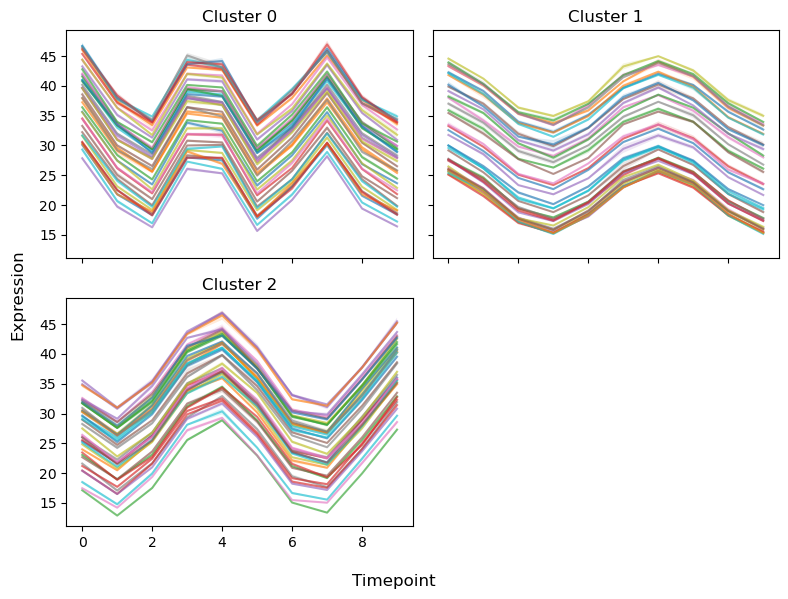

In [46]:
plot_cluster_profiles(expr_df_1, annot_1)

Plotting the location of each gene in parameter space 

In [25]:
def plot_latent_cluster_structure(latent_params_df):

    fig, (ax_goi, ax_bg) = plt.subplots(1, 2, figsize=(12,6))

    # global frequency colour scale
    fmin = latent_params_df["f_unit"].min()
    fmax = latent_params_df["f_unit"].max()

    # GOI clusters
    goi = latent_params_df[
    latent_params_df["Cluster"].notna() &
    (latent_params_df["Cluster"] != "bg_cluster")
    ]

    markers = ["o", "s", "^", "D", "P", "X", "*"]

    for cluster_id in sorted(goi["Cluster"].unique()):
        subset = goi[goi["Cluster"] == cluster_id]
        marker = markers[int(cluster_id) % len(markers)]
        sc = ax_goi.scatter(subset["p_unit"], subset["a_unit"], c=subset["f_unit"], cmap="viridis",
            vmin=fmin, vmax=fmax, marker=marker, alpha=0.8, label=f"Cluster {cluster_id}")

    ax_goi.set_xlabel("Phase (latent)")
    ax_goi.set_ylabel("Amplitude (latent)")
    ax_goi.set_title("GOI Cluster Structure")
    ax_goi.legend()

     # Background genes

    bg_free = latent_params_df[latent_params_df["Cluster"].isna()]

    ax_bg.scatter(
        bg_free["p_unit"],
        bg_free["a_unit"],
        c=bg_free["f_unit"],
        cmap="viridis",
        vmin=fmin,
        vmax=fmax,
        alpha=0.2,
        s=10,
        label="Background random"
    )

    # Only plot a background cluster if one exists
    if "bg_cluster" in latent_params_df["Cluster"].values:

        bg_cluster = latent_params_df[
            latent_params_df["Cluster"] == "bg_cluster"
        ]

        ax_bg.scatter(
            bg_cluster["p_unit"],
            bg_cluster["a_unit"],
            c=bg_cluster["f_unit"],
            cmap="viridis",
            vmin=fmin,
            vmax=fmax,
            marker="x",
            s=25,
            label="Background coexpressed"
        )

    ax_bg.set_xlabel("Phase (latent)")
    ax_bg.set_ylabel("Amplitude (latent)")
    ax_bg.set_title("Background Gene Space")
    ax_bg.legend()

    # Colorbar in its own axis

    from mpl_toolkits.axes_grid1 import make_axes_locatable

    divider = make_axes_locatable(ax_bg)
    cax = divider.append_axes("right", size="5%", pad=0.1)


    sm = ScalarMappable(
        norm=Normalize(vmin=fmin, vmax=fmax),
        cmap="viridis"
    )
    sm.set_array([])

    cbar = plt.colorbar(sm, cax=cax)
    cbar.set_label("Frequency (latent)")

    plt.tight_layout()
    plt.show()

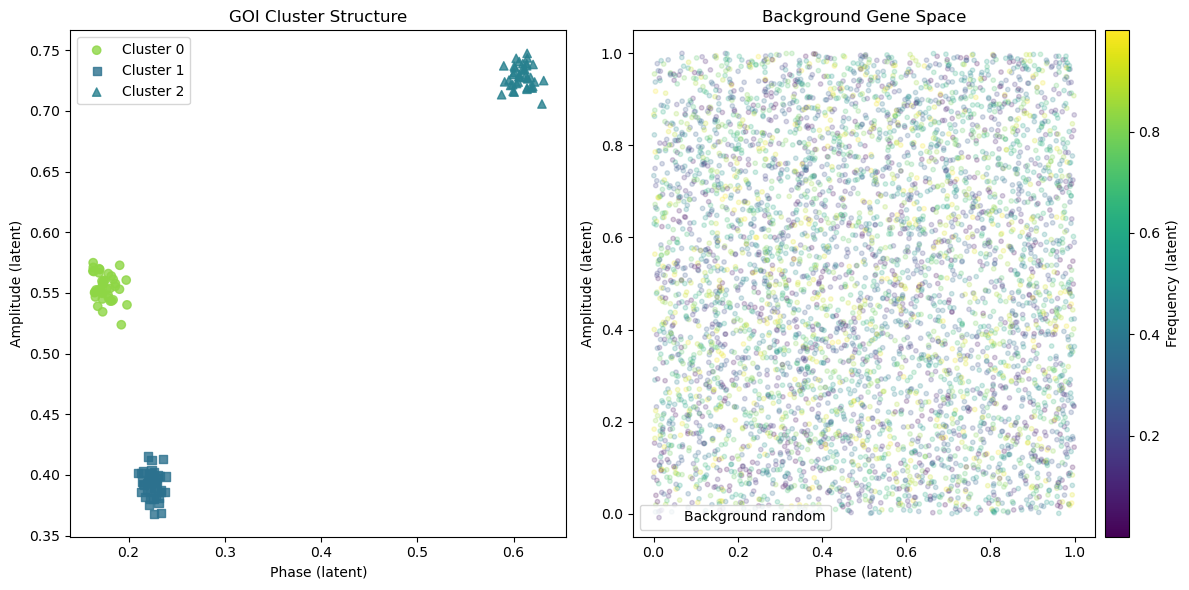

In [47]:
plot_latent_cluster_structure(latent_params_df_1)